<a href="https://colab.research.google.com/github/PedroMatumoto/ai_notebooks/blob/main/IMT_regressao_scale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->


# **Aprendizado Supervisionado e Regressão Linear `statsmodels`**

Neste laboratório:

1. Aplique os modelos de regressão linear com statsmodel e scikit-learn
2. Entenda os efeitos da normalização
3. Avalie o uso de diferentes preditores e seu impacto sobre a variável objetivo




In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import statsmodels.formula.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Caso: **Estimando o preço de imóveis**

Empregue modelos de regressão simples e múltipla para estimar o preço dos imóveis.


In [11]:
df = pd.read_excel('http://meusite.mackenzie.br/rogerio/data_load/regressao_preco_imoveis.xlsx')
df.head()

,bairro,areaM2,suites,dormitorios,banheiros,vagas,preco
0,vila-nova-conceicao,32,1,1,1,1,490000
1,vila-nova-conceicao,157,2,2,2,2,3180000
2,vila-nova-conceicao,205,2,3,3,3,1900000
3,vila-nova-conceicao,193,3,3,3,3,3565000
4,vila-nova-conceicao,116,1,3,2,2,1605000


## Exploração inicial dos dados

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   bairro       3741 non-null   object
 1   areaM2       3741 non-null   int64 
 2   suites       3741 non-null   int64 
 3   dormitorios  3741 non-null   int64 
 4   banheiros    3741 non-null   int64 
 5   vagas        3741 non-null   int64 
 6   preco        3741 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 204.7+ KB


In [13]:
df.describe()

,areaM2,suites,dormitorios,banheiros,vagas,preco
count,3741.000000,3741.000000,3741.000000,3741.000000,3741.000000,3.741000e+03
mean,140.343758,1.700882,2.946271,3.095429,2.225341,1.553746e+06
std,60.051791,0.994945,0.759292,1.372859,1.000940,1.073607e+06
min,20.000000,1.000000,1.000000,1.000000,1.000000,2.800000e+05
25%,94.000000,1.000000,3.000000,2.000000,1.000000,8.500000e+05
50%,130.000000,1.000000,3.000000,3.000000,2.000000,1.200000e+06
75%,180.000000,2.000000,3.000000,4.000000,3.000000,1.880000e+06
max,299.000000,6.000000,6.000000,9.000000,5.000000,8.000000e+06


# Q1.

Considere somente os dados numéricos, sem transformações. Qual o R2 obtido da regressão linear para estimativa do preço dos imóveis?

In [14]:
import statsmodels.formula.api as sm
model = sm.ols(formula='preco ~ suites + dormitorios + banheiros + vagas + areaM2 - 1 ', data=df)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              6589.
Date:                Wed, 27 Aug 2025   Prob (F-statistic):                        0.00
Time:                        22:25:48   Log-Likelihood:                         -55098.
No. Observations:                3741   AIC:                                  1.102e+05
Df Residuals:                    3736   BIC:                                  1.102e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
suites       2.127e+05   1.62e+04     13.106      0.000    1.81e+05    2.45e+05
dormitorios  -3.04e+05   1.24e+04    -24.586      0.000   -3.28e+05    -2.8e+05
banheiros   -1.678e+04   1.03e+04     -1.624      0.104    -3.7e+04    3476.725
vagas        2.993e+05   1.57e+04     19.070      0.000    2.69e+05     3.3e+05
areaM2        1.05e+04    272.657     38.508      0.000    9964.927     1.1e+04
==============================================================================
Omnibus:                     1113.081   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7936.197
Skew:                           1.225   Prob(JB):                         0.00
Kurtosis:                       9.702   Cond. No.                         300.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Q2.

Considere somente os dados numéricos, sem transformações. Quais atributos preditores são significativos?

In [15]:
print(' Suites, dormitorios, vagas, areaM2')

 Suites, dormitorios, vagas, areaM2


# Q3.

Considere somente os dados numéricos, sem transformações. Qual o R2 obtido somente com os coeficientes significativos?

In [16]:
result = model.fit()
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              8233.
Date:                Wed, 27 Aug 2025   Prob (F-statistic):                        0.00
Time:                        22:25:48   Log-Likelihood:                         -55099.
No. Observations:                3741   AIC:                                  1.102e+05
Df Residuals:                    3737   BIC:                                  1.102e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
suites       2.029e+05   1.51e+04     13.463      0.000    1.73e+05    2.32e+05
dormitorios -3.124e+05   1.12e+04    -27.814      0.000   -3.34e+05    -2.9e+05
vagas        2.965e+05   1.56e+04     19.003      0.000    2.66e+05    3.27e+05
areaM2       1.047e+04    272.161     38.474      0.000    9937.637     1.1e+04
==============================================================================
Omnibus:                     1116.289   Durbin-Watson:                   1.383
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7964.356
Skew:                           1.229   Prob(JB):                         0.00
Kurtosis:                       9.712   Cond. No.                         291.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Q4.

Considere somente os dados numéricos, sem transformações. Considerando somente os coeficientes significativos da regressão linear, qual o preço estimado de um imóvel de 134 m2, uma suite, 4 dormitórios e 2 vagas de garagem?


In [17]:
# predizer o perco
value_price = result.predict({'suites':1, 'dormitorios':4, 'vagas':2, 'areaM2':134})
print('O valor estimado é de: ', value_price)


O valor estimado é de:  0    949268.265645
dtype: float64


# Q5.

Podemos afirmar que o atributo que influencia mais o preço em termos absolutos é o número de dormitórios (Verdadeiro/Falso)?

In [18]:
print("Errado, pois os dados ainda não estão normalizados")

Errado, pois os dados ainda não estão normalizados


# Scale 1

# Q6.

Normalize os dados, incluindo o preço, apenas dividindo pelo valor máximo de cada atributo e refaça a regressão linear somente os preditores significativos. Qual a estimativa do preço agora?

In [20]:
# normalizar os dados
df_norm = df.copy()
df_norm['suites'] = df_norm['suites']/df_norm['suites'].max()
df_norm['dormitorios'] = df_norm['dormitorios']/df_norm['dormitorios'].max()
df_norm['banheiros'] = df_norm['banheiros']/df_norm['banheiros'].max()
df_norm['vagas'] = df_norm['vagas']/df_norm['vagas'].max()
df_norm['areaM2'] = df_norm['areaM2']/df_norm['areaM2'].max()
df_norm['preco'] = df_norm['preco']/df_norm['preco'].max()

# fazer o modelo
model = sm.ols(formula='preco ~ suites + dormitorios + banheiros + vagas + areaM2 - 1', data=df_norm)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              6589.
Date:                Wed, 27 Aug 2025   Prob (F-statistic):                        0.00
Time:                        22:26:20   Log-Likelihood:                          4365.3
No. Observations:                3741   AIC:                                     -8721.
Df Residuals:                    3736   BIC:                                     -8689.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
suites          0.1595      0.012     13.106      0.000       0.136       0.183
dormitorios    -0.2280      0.009    -24.586      0.000      -0.246      -0.210
banheiros      -0.0189      0.012     -1.624      0.104      -0.042       0.004
vagas           0.1871      0.010     19.070      0.000       0.168       0.206
areaM2          0.3924      0.010     38.508      0.000       0.372       0.412
==============================================================================
Omnibus:                     1113.081   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7936.197
Skew:                           1.225   Prob(JB):                         0.00
Kurtosis:                       9.702   Cond. No.                         11.8
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Q7.

Qual atributo influencia mais no preço dos imóveis segundo seu modelo agora?

In [21]:
print('A área em m² foi a mais relevante')

A área em m² foi a mais relevante


# Scale 2

# Qa.

Verifique que os mesmos resultados podem ser obtidos normalizando apenas as variáveis preditoras.




In [22]:
df_norm_predi = df.copy()
df_norm['suites'] = df_norm['suites']/df_norm['suites'].max()
df_norm['dormitorios'] = df_norm['dormitorios']/df_norm['dormitorios'].max()
df_norm['banheiros'] = df_norm['banheiros']/df_norm['banheiros'].max()
df_norm['vagas'] = df_norm['vagas']/df_norm['vagas'].max()
df_norm['areaM2'] = df_norm['areaM2']/df_norm['areaM2'].max()

model = sm.ols(formula='preco ~ suites + dormitorios + banheiros + vagas + areaM2 - 1', data=df_norm)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  preco   R-squared (uncentered):                   0.898
Model:                            OLS   Adj. R-squared (uncentered):              0.898
Method:                 Least Squares   F-statistic:                              6589.
Date:                Wed, 27 Aug 2025   Prob (F-statistic):                        0.00
Time:                        22:26:32   Log-Likelihood:                          4365.3
No. Observations:                3741   AIC:                                     -8721.
Df Residuals:                    3736   BIC:                                     -8689.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
suites          0.1595      0.012     13.106      0.000       0.136       0.183
dormitorios    -0.2280      0.009    -24.586      0.000      -0.246      -0.210
banheiros      -0.0189      0.012     -1.624      0.104      -0.042       0.004
vagas           0.1871      0.010     19.070      0.000       0.168       0.206
areaM2          0.3924      0.010     38.508      0.000       0.372       0.412
==============================================================================
Omnibus:                     1113.081   Durbin-Watson:                   1.385
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7936.197
Skew:                           1.225   Prob(JB):                         0.00
Kurtosis:                       9.702   Cond. No.                         11.8
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Scale 3

# Qb.

Verifique agora para o esquema de normalização **MinMAx**  (pode fazer sem empregar o scikit-learn) e refaça a regressão linear com os preditores significativos. Qual a estimativa do preço agora? Qual a sua conclusão?


In [29]:
# utilizar min max para normalizar
df_norm = df.copy()
df_norm['suites'] = (df_norm['suites'])/(df_norm['suites'].max())
df_norm['dormitorios'] = (df_norm['dormitorios'])/(df_norm['dormitorios'].max())
df_norm['vagas'] = (df_norm['vagas'] )/(df_norm['vagas'].max() )
df_norm['areaM2'] = (df_norm['areaM2'] )/(df_norm['areaM2'].max() )

model = sm.ols(formula='preco ~ suites + dormitorios + vagas + areaM2 - 1', data=df_norm)
result = model.fit()
result.summary()

# fazer a predicao
# normalizacao dos dados de predição
normalized_suites = (1) / (df['suites'].max())
normalized_dormitorios = (4 ) / (df['dormitorios'].max() )
normalized_vagas = (2 ) / (df['vagas'].max() )
normalized_areaM2 = (134 ) / (df['areaM2'].max() )

value_price = result.predict({'suites':normalized_suites, 'dormitorios':normalized_dormitorios, 'vagas':normalized_vagas, 'areaM2':normalized_areaM2})

print('O valor estimado é de: ', value_price)


O valor estimado é de:  0    949268.265645
dtype: float64


# Q9.

Faça um gráfico dos dados para verificar os aspectos de outliers e homocedasticidade dos dados.


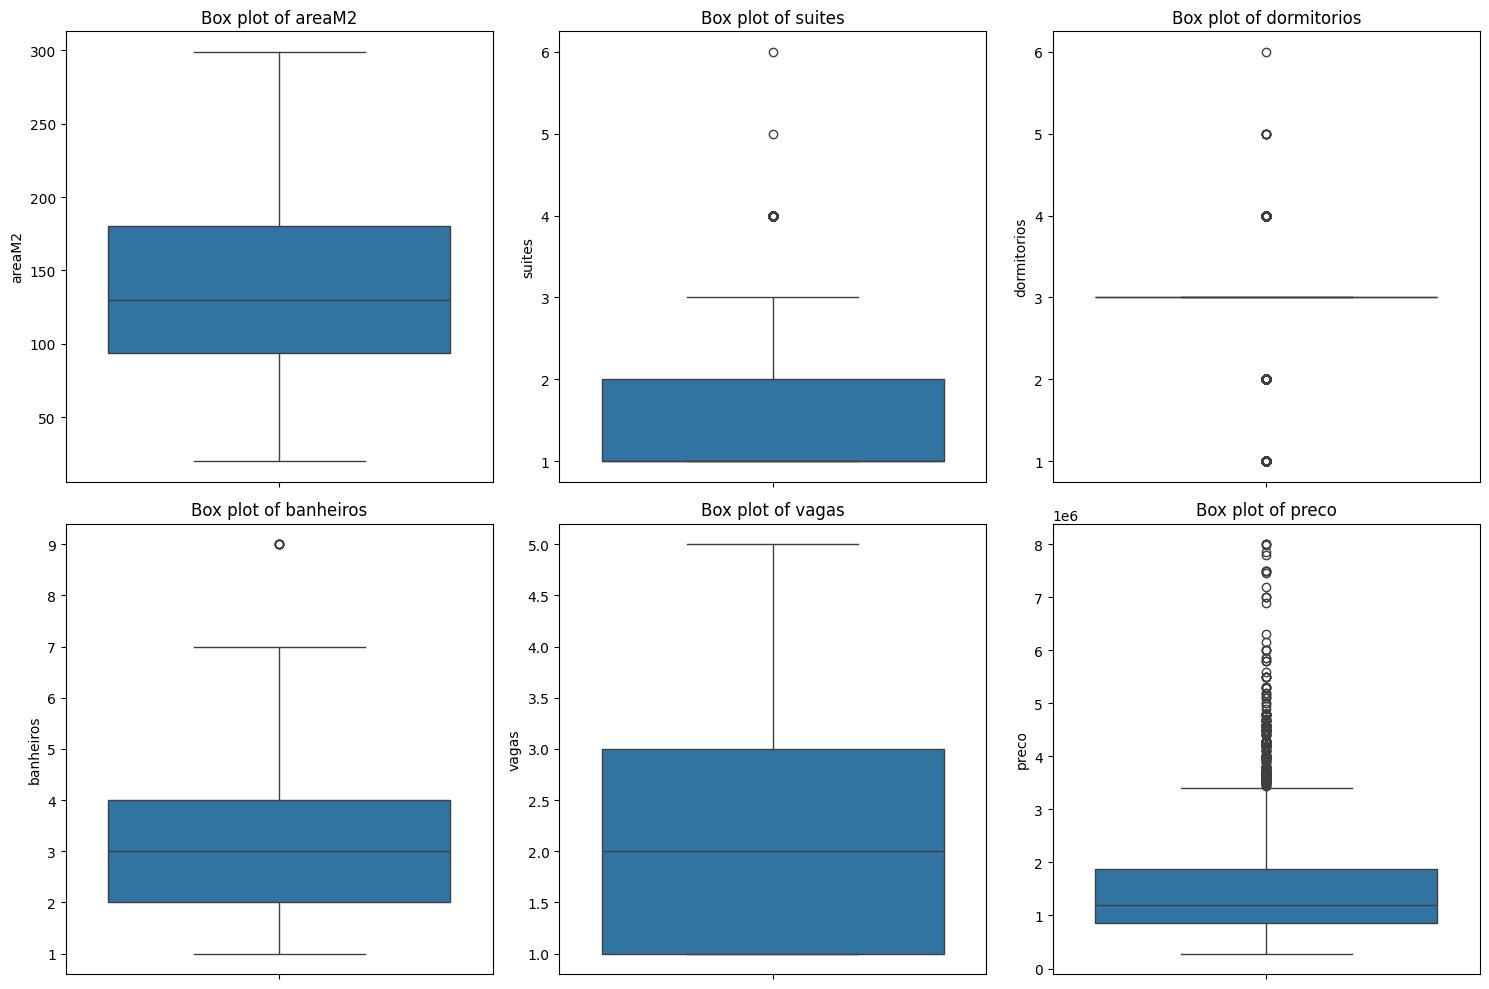

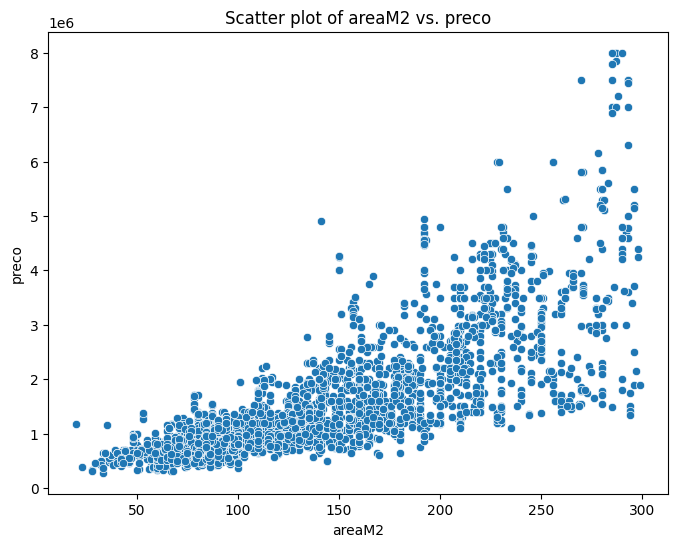

In [34]:
# Box plots for numerical features to identify outliers
numerical_cols = ['areaM2', 'suites', 'dormitorios', 'banheiros', 'vagas', 'preco']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

continuous_cols = ['areaM2']
for col in continuous_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[col], y=df['preco'])
    plt.title(f'Scatter plot of {col} vs. preco')
    plt.xlabel(col)
    plt.ylabel('preco')
    plt.show()

# Q10.

Construa o mesmo modelo, com os 4 preditores significativos, com o Scikit-learn. Por que diferente?

In [45]:
model = LinearRegression()
X = df[['suites', 'dormitorios', 'vagas', 'areaM2']]
y = df['preco']
model.fit(X, y)

dict_a = {'suites':1, 'dormitorios':4, 'vagas':2, 'areaM2':134}
y_pred = model.predict(pd.DataFrame(dict_a, index=[0]))
print("y_pred: ", y_pred)

y_pred:  [950278.0028635]


# Q11.

Faça o modelo sm.ols incluindo todas as variáveis preditoras, mesmo o bairro que é não numérico, e veja como a api se comporta para criar o modelo. Faça a previsão para o mesmo case considerando o bairro de `vila-mariana`. Observe as variáveis preditoras no summary do modelo. O que aconteceu?

In [50]:
model = sm.ols(formula='preco ~ suites + dormitorios + vagas + areaM2 +bairro - 1', data=df)
result = model.fit()
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  preco   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     1812.
Date:                Wed, 27 Aug 2025   Prob (F-statistic):               0.00
Time:                        22:50:42   Log-Likelihood:                -54290.
No. Observations:                3741   AIC:                         1.086e+05
Df Residuals:                    3732   BIC:                         1.087e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
bairro[morumbi]              -3.14e+05   5.33e+04     -5.887      0.000   -4.19e+05   -2.09e+05
bairro[paraiso]             -2.312e+05   3.72e+04     -6.218      0.000   -3.04e+05   -1.58e+05
bairro[vila-mariana]        -4.321e+05   3.49e+04    -12.392      0.000   -5.01e+05   -3.64e+05
bairro[vila-nova-conceicao]  4.549e+05   3.45e+04     13.172      0.000    3.87e+05    5.23e+05
bairro[vila-sonia]          -8.387e+05   4.41e+04    -19.035      0.000   -9.25e+05   -7.52e+05
suites                       1.561e+05   1.23e+04     12.700      0.000    1.32e+05     1.8e+05
dormitorios                 -9.795e+04   1.47e+04     -6.683      0.000   -1.27e+05   -6.92e+04
vagas                        3.337e+05   1.35e+04     24.631      0.000    3.07e+05     3.6e+05
areaM2                       7591.9890    240.241     31.602      0.000    7120.973    8063.005
==============================================================================
Omnibus:                     1314.663   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12354.953
Skew:                           1.400   Prob(JB):                         0.00
Kurtosis:                      11.451   Cond. No.                     1.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [52]:
dict_a = {'suites':1, 'dormitorios':4, 'vagas':2, 'areaM2':134, 'bairro':'vila-mariana'}
y_pred = result.predict(pd.DataFrame(dict_a, index=[0]))
print("y_pred: ", y_pred)

y_pred:  0    1.016884e+06
dtype: float64
